# Image Classification ML Assignment 

The goal of this assignment is to learn fundamentals of machine learning and image analysis. You will analyze images from Happy Whale, an organization that tracks whales globally, and modify a classifier for these images. 

Part 1: Walk through (Due Feb 27)
- In class, we will walk through the provided code
- This script has several functions that are written for you. For part 1, please do NOT modify any code unless it specifies to change it.
- Answer the questions as you go through the code

Part 2: Make modifications (Due Feb 27)
- Change model parameters or other model aspects at least 3 times 
- Describe what happened when you made these changes

Part 3: Create a team, get inspired and try a new approach to your model (Due March 6)
- Have a group meeting and record your meeting with audio or video (you can record with zoom!)
    - Start by discussing part 2 of the assignment:
        - What approaches you each took to change the ML model in part 2
        - What are similarities and differences between your approaches 
        - What types of changes improved model performance
        - What types of changes made model performance worse
        - Based on the whole group's work, what would y'all want to do next in terms of model optimization?
    - Next, look at code and approaches from the [Happy Whales competition leaderboard](https://www.kaggle.com/competitions/happy-whale-and-dolphin/leaderboard).
        - Is there any strategy that someone used that you could implement? 
            - Ex: learning rate value, # epochs, transformation strategy, or more complex changes to the models
        - Are there strategies that you are interested in learning about?
    - Lastly, make a plan for 1 more round of model optimization
        - Assign each member something to attempt for training the model. Use your cumulative experience to decide the most important things to test. 
        - Group members can make as small as changing the value for a parameter or as big as changing the model.
- Have each member complete their test
- Share results with each other
- Write a 1-3 paragraph summary on your group's attempts and recommendations moving forward
- For Part 3: Turn in the audio/video recording of the group meeting, each member's code (uploaded to their original git repo), and the team's 1-3 paragraph summary over canvas.

### Your choices on data
You can chose between 3 datasets for this assignment. This jupyter notebook is set up using the Species dataset. If you change the dataset, you will need to change the number of classes parameter for the model.
- Species = you will classify images by species (gray, killer, beluga, humpback, false killer, and common dolphin)
  - File path: /projects/bgmp/shared/Bi625/ML_Assignment/Datasets/Whale_species/species
- Species_all = you will classify images by species (minke, gray, killer, beluga, humpback, false killer, and bottlenose and common dolphin). There are a high number of images for bottlenose dolphins and minke whales which leads to this dataset being quite large. Due to the size of the dataset, it has a longer training time than the "Species" dataset.
  - File path: /projects/bgmp/shared/Bi625/ML_Assignment/Datasets/Whale_species/species_all
  - Num classes: 8
- Individuals = you will classify images by individuals. This is a much more challenging classification task because you have different individuals from different species. However, this was the original goal of the Happy Whale competition, so try challenging yourself to this important task!
  - File path: /projects/bgmp/shared/Bi625/ML_Assignment/Datasets/Whale_species/individuals
  - Num classes: 110

You are NOT graded by the success of your model, so you are free to train the model on whichever dataset is more interesting to you. However, **everyone on your team for part 3 should be using the same dataset**.

### Part 1

In [18]:
## Importing packages - Please DO NOT alter this box ##
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
from torch.nn import functional as F
import torch.optim as optim
from torch.utils.data.sampler import WeightedRandomSampler
torch.manual_seed(0)

from captum.attr import IntegratedGradients
from captum.attr import DeepLift
from captum.attr import NoiseTunnel
from captum.attr import visualization as viz

import torchvision
from torchvision import datasets, transforms
from torch.utils.tensorboard import SummaryWriter
writer = SummaryWriter()

import os
import imageio
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from tqdm import tqdm
from scipy.ndimage import binary_erosion
import pandas as pd
from sklearn.metrics import confusion_matrix
import seaborn as sns

import wandb #comment this out if you are not using weights and biases
import random #comment this out if you are not using weights and biases

# Set device to cuda if it's available otherwise default to "cpu"
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

### Loading in the dataset

By default, this will load in the species dataset, this is the smallest dataset (i.e., it will be relatively fast to train) and has a simple goal (i.e., you will be able to create an accurate model). If you want a challenge, I highly encourage you to try the Species_all (a dataset with 2 additional species) or the individual dataset (a dataset where whales are characterized by individual rather than species).

In [2]:
images = "/projects/bgmp/shared/Bi625/ML_Assignment/Datasets/Whale_species/species"

In [25]:
# We must turn our images into tensors, resize, and normalize them 
# We can also add additional transformations to images 
transform = transforms.Compose([transforms.ToTensor(), 
                                #We will start with a model called Resnet18 that is optimized for 224x224 images
                                #It is set to a very SMALL size initially so the model will train fast in class
                                transforms.Resize([32,32]),
                                transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # Normalize the data, these are the values that ResNet suggests based on their training data (natural scences)
                               ])
all_images = datasets.ImageFolder(images, transform)
print(all_images)

Dataset ImageFolder
    Number of datapoints: 2794
    Root location: /projects/bgmp/shared/Bi625/ML_Assignment/Datasets/Whale_species/species
    StandardTransform
Transform: Compose(
               ToTensor()
               Resize(size=[32, 32], interpolation=bilinear, max_size=None, antialias=warn)
               Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
           )


<font color='magenta'>What is the purpose(s) of transforming image data? (2 pts)

*Neural Networks work on tensors not image objects so first we transform to a PyTorch tensor where the pixels are turned into numbers that the model can compute on.then we resize the image for faster training and lower memory usage.*

<font color='green'>The below code completes the image transformations as coded in the above box.

In [26]:
all_images = datasets.ImageFolder(images, transform )
print(len(all_images))
print(all_images)

2794
Dataset ImageFolder
    Number of datapoints: 2794
    Root location: /projects/bgmp/shared/Bi625/ML_Assignment/Datasets/Whale_species/species
    StandardTransform
Transform: Compose(
               ToTensor()
               Resize(size=[32, 32], interpolation=bilinear, max_size=None, antialias=warn)
               Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
           )


Our classification labels will be converted to indices, we can determine which indices is which label using the below code

In [27]:
print(all_images.class_to_idx)

{'beluga': 0, 'common_dolphin': 1, 'false_killer_whale': 2, 'fin_whale': 3, 'gray_whale': 4, 'humpback_whale': 5}


<font color='green'>The below function is used to randomly select dataset images to evaluate how the transformations altered the images.

In [28]:
def show_random_dataset_image(dataset):
    idx = np.random.randint(0, len(dataset))    # take a random sample
    img, mask = dataset[idx]                    # get the image and the nuclei masks
    f, axarr = plt.subplots(1, 2)               # make two plots on one figure
    axarr[0].imshow(img[0], cmap="viridis")                     # show the image, cmap is the color map that the image is being shown in
    #axarr[1].imshow(mask[0])                    # show the masks
    _ = [ax.axis('off') for ax in axarr]        # remove the axes
    print('Image size is %s' % {img[0].shape})
    print(img.shape)
    plt.show()

Image size is {torch.Size([32, 32])}
torch.Size([3, 32, 32])


/packages/miniconda-t2/20230523/envs/jupyter-cuda121-20230610/lib/python3.8/site-packages/torchvision/transforms/functional.py:1603: UserWarning: The default value of the antialias parameter of all the resizing transforms (Resize(), RandomResizedCrop(), etc.) will change from None to True in v0.17, in order to be consistent across the PIL and Tensor backends. To suppress this warning, directly pass antialias=True (recommended, future default), antialias=None (current default, which means False for Tensors and True for PIL), or antialias=False (only works on Tensors - PIL will still use antialiasing). This also applies if you are using the inference transforms from the models weights: update the call to weights.transforms(antialias=True).
  warnings.warn(


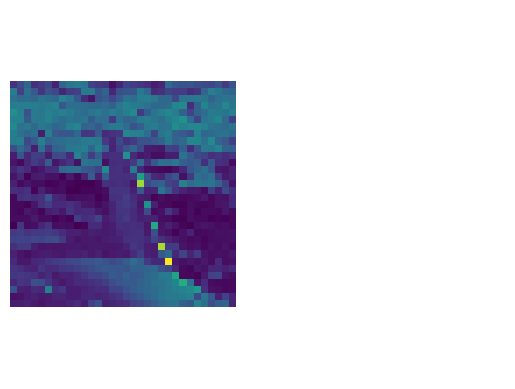

In [29]:
show_random_dataset_image(all_images)

<font color='magenta'>What is the difference between image size and torch image size? (2 pts)

*The image size of 32 by 32 just represents height and width while the torch image size with the added dimension of 3 shows the number of channels*

<font color='magenta'>Add a new transformation to the training data. After your first run of this model during class time, resize the image to 224x224 pixels. (2 pts)

Image size is {torch.Size([224, 224])}
torch.Size([3, 224, 224])


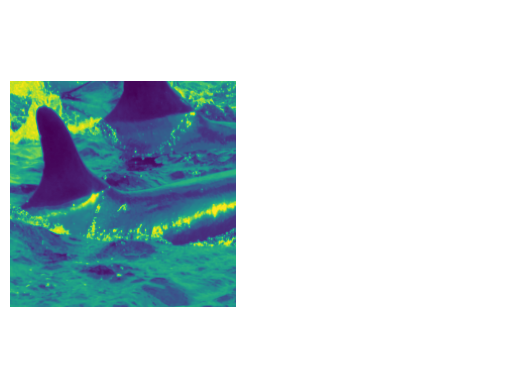

In [30]:
## ADD YOUR TRANSFORMATION HERE
transform = transforms.Compose([
            transforms.Resize([224,224]), # Resize the image as our model is optimized for 224x224 pixels
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])]) # Normalize the data, these are the values that ResNet suggests based on their training data (natural scences))

all_images = datasets.ImageFolder(images, transform )
show_random_dataset_image(all_images)

<font color='magenta'>How did your transformation impact the images? (1 pt)

*The transformation really helped with detecting edges, shapes, and texture. I can clearly see a fin now.*

### Creating datasets used in training and testing

After loading in the data, we separate the data into training, validation, and testing datasets. The training data is inputted into the model during the training phase, and the model's predictions from this data is used to modulate the weights of the model. The validation data is used while the model trains, but the model is in a evaluation rather than training mode. The validation data gives us a real time view on how accurately the model is predicting our labels. The testing data is used after the model has completed training and tells us how successful our model will be with a novel dataset.

Once creating these 3 datasets, we prepare dataloaders which are used to load the images into our models. These images are loaded in batches into the model (a parameter called batch size). Because our dataset is imbalanced, we use a weighted random sampler to select images for our batches in the dataloader. Therefore to create our dataloader, we start by creating a function to get weights, calculating weights, initiating our weighted random sampler, and then creating our dataloaders.

<font color='green'>The below code eastablishes the data split between training, validation, and testing.

In [31]:
train_size = int(0.7 * len(all_images))
val_size = int(0.15 * len(all_images))
test_size = len(all_images) - (train_size + val_size)
print(train_size, val_size, test_size)
assert train_size + val_size + test_size == len(all_images)

1955 419 420


In [32]:
train_set, val_set, test_set = torch.utils.data.random_split(all_images, [train_size, val_size, test_size])

<font color='green'>The below function is used to get weights for the image classes.

In [33]:
def _get_weights(subset,full_dataset):
    ys = np.array([y for _, y in subset])
    counts = np.bincount(ys)
    label_weights = 1.0 / counts
    weights = label_weights[ys]

    print("Number of images per class:")
    for c, n, w in zip(full_dataset.classes, counts, label_weights):
        print(f"\t{c}:\tn={n}\tweight={w}")
        
    return weights

In [34]:
train_weights = _get_weights(train_set,all_images)
train_sampler = WeightedRandomSampler(train_weights, len(train_weights))

Number of images per class:
	beluga:	n=458	weight=0.002183406113537118
	common_dolphin:	n=43	weight=0.023255813953488372
	false_killer_whale:	n=713	weight=0.001402524544179523
	fin_whale:	n=131	weight=0.007633587786259542
	gray_whale:	n=56	weight=0.017857142857142856
	humpback_whale:	n=554	weight=0.0018050541516245488


<font color='magenta'>What is the impact of the class weight on how data is loaded into the model? What does it mean if a class has a low vs high weight? (2 pts)

<details>
  <summary>Hint</summary>
  
Check out this resource: https://towardsdatascience.com/demystifying-pytorchs-weightedrandomsampler-by-example-a68aceccb452 


*For example, the false killer whale has a very low weight which means that a lot of samples exist so theres a loq probability of each individual sample being drawn. For the high weight classes like gray whale there are few samples so each sample has a high probability of being drawn. This is basically a class balancing step.*

In [35]:
train_loader = DataLoader(train_set, batch_size=48, drop_last=True, sampler=train_sampler)
val_loader = DataLoader(val_set, batch_size=48, drop_last=True, shuffle=True)
test_loader = DataLoader(test_set, batch_size=48, drop_last=True, shuffle=True)

### Picking hyperparameters

We can set a few hyperparameters that we decide and can tune. These include:

- Learning rate = how much to update our model's parameters at each batch/epoch
- batch size = the number of data samples to pass through the network before updating it
    - If you change the batchsize below, make sure you ALSO change it in the commands above for the DataLoader
- Number of epochs = # of times to iterate over the dataset in model training

In [14]:
learning_rate=1e-3
batchsize=48
epochs=5

<font color='magenta'>How would model training be impacted if we decreased our learning rate? What about if we increased it? (2 pts)

*If we decreased the learning rate the model would be slower but more stable and if we increased the learning rate the model would be faster but training is riskier and noiseier.*

### Training our model

For part 1, we are going to use the model ResNet18. This is a published model for imaging data. Resnet18 is built from 4 residual blocks with two convolutional layers (Conv2d). Each convolutional layer is followed by a batch normalization step (BatchNorm2D) and a ReLU activation layer (ReLU). There is also a shortcut connection which adds input to output and allows the network to learn residual mapping.

I provided the complete code for the ResNet18 model. In the future, if you want to use resnet18, you can load it simply by running `resnet18_model = torchvision.models.resnet18(weights = False, progress  = True, num_classes=XXX)`. We will look at the full code for the model so you can see how this model was created.  

<font color='green'>The below code builds the residual blocks that ResNet18 uses in the model.

In [15]:
## First, we create the basic block that will be used in our residual net
class BasicBlock(nn.Module):
    # Initializing method for the basic block (It's OOP!)
    def __init__(self, in_channels, out_channels, stride=1):
        super(BasicBlock, self).__init__()
        ## Conv1: convolution layer, batch normalization, ReLU activation
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

        ## Conv2: convolution layer, batch normalization
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        ## Shortcut connection: adds input to output
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    # The forward method calls on each layer
    def forward(self, x):
        ## Conv1: convolution layer, batch normalization, ReLU activation
        out = self.conv1(x) 
        out = self.bn1(out)
        out = self.relu(out)
        ## Conv2: convolution layer, batch normalization
        out = self.conv2(out)
        out = self.bn2(out)
        ## Shortcut connection
        out += self.shortcut(x)
        ## Final activation
        out = self.relu(out)
        return out

<font color='green'>The below code builds and initializes the ResNet18 model.

In [16]:
## Next, we put together these building blocks and create our residual net
class ResNet18(nn.Module):
    # specify the number of classes that we are predicting
    def __init__(self, num_classes=6):
        super(ResNet18, self).__init__()
        # In channels = Num pixels in H + Num pixels in W
        self.in_channels = 64
        
        # First convolution set (convolution, batch norm, relu)
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)

        # Our building blocks
        # The numbers correspond to the matrix shape
        ### We increase the number of filters/channels (i.e., the first number) as we go
        self.layer1 = self._make_layer(BasicBlock, 64, 2, stride=1)
        self.layer2 = self._make_layer(BasicBlock, 128, 2, stride=2)
        self.layer3 = self._make_layer(BasicBlock, 256, 2, stride=2)
        self.layer4 = self._make_layer(BasicBlock, 512, 2, stride=2)

        # Average pooling 
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))

        # Final layer that makes the classification
        self.fc = nn.Linear(512, num_classes)

    def _make_layer(self, block, out_channels, num_blocks, stride):
        strides = [stride] + [1]*(num_blocks-1)
        layers = []
        for stride in strides:
            layers.append(block(self.in_channels, out_channels, stride))
            self.in_channels = out_channels
        return nn.Sequential(*layers)

    def forward(self, x):
        # First convolution set (convolution, batch norm, relu)
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        # Our 4 building blocks
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)
        
        out = self.avgpool(out)
        out = out.view(out.size(0), -1)
        # Final layer that makes the classification
        out = self.fc(out)
        return out

## Getting our model and transferring it to the GPU
model = ResNet18().to(device)
print(model)

ResNet18(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (shortcut): Sequential()
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=

<font color='green'>The below code eastablishes the loss function and optimizer used in training the model.

In [17]:
#define loss function & optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

<font color='green'>The below functions are used to train, evaluate, and test the Machine Learning model.

In [27]:
wandb.init(
    project="BGMP_HappyWhale",
    name="Daniella-HappyWhale-SpeciesDataset-hyperparameters", ### Update with your name!
    config={"learning rate":0.001,
        "architecture": "CNN",
        "dataset": "Species",
        "epochs":5}
)

num_epochs = epochs

for epoch in range(num_epochs):
    # Setting model to "training mode"
    model.train()
    running_loss = 0.0
    correct, total = 0, 0
    batch=0

    # For each batch of data within the loader
    for inputs, labels in train_loader:
        # Send our input images and their labels to the GPU
        inputs, labels = inputs.to(device), labels.to(device)
        # Zero the gradients
        optimizer.zero_grad()
        # Inputting our training images into the model
        # and Predicting the image classification label
        outputs = model(inputs)
        # Figuring out the loss from our predictions
        loss = criterion(outputs, labels)
        # Compute gradients (aka backward pass)
        loss.backward()
        # Update model parameters
        optimizer.step()

        # Adding the loss to our running sum
        # Loss is calculated for each batch within an epoch
        running_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        batch+=1
        print(f'Epoch [{epoch+1}/{num_epochs}] | Batch #{batch} | Batch Accuracy {(correct/total)*100:.2f}%')


    # Getting metrics for our training pass 
    train_loss = running_loss / len(train_loader.dataset)
    train_acc = 100. * correct / total
    train_losses.append(train_loss)
    train_acc_list.append(train_acc)
    
    # Switching our model to "evaluation mode"
    model.eval()
    running_loss = 0.0
    correct, total = 0, 0
    # Disable gradient calculation b/c we are evalulating the model
    with torch.no_grad():
        # Load in batches of our validation data
        for inputs, labels in val_loader:
            # Send test images and labels to the GPU
            inputs, labels = inputs.to(device), labels.to(device)
            # Predict the image classification label
            outputs = model(inputs)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            # Figuring out how many predicted labels = true labels
            correct += predicted.eq(labels).sum().item()

            # Figuring out the loss from our predictions
            loss = criterion(outputs, labels)
            # Adding the loss to our running sum
            # Loss is calculated for each batch within an epoch
            running_loss += loss.item() * inputs.size(0)
    # Getting our accuracy from our test data
    val_acc = 100. * correct / total
    val_acc_list.append(val_acc)
    # Getting the loss from our test data
    val_loss = running_loss / len(val_loader.dataset)
    val_losses.append(val_loss)
    
    print(f'Epoch [{epoch+1}/{num_epochs}] Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}% | Val Loss: {val_loss:.2f}%')

    # log metrics to wandb
    wandb.log({"validation_accuracy": val_acc, "validation_loss": val_loss, "train_loss":train_loss})

wandb.finish()

Epoch [1/5] | Batch #1 | Batch Accuracy 39.58%
Epoch [1/5] | Batch #2 | Batch Accuracy 40.62%
Epoch [1/5] | Batch #3 | Batch Accuracy 43.75%


KeyboardInterrupt: 

#### For our class training, run the below model and consider the success of the model training. 

<font color='magenta'>What is your starting accuracy and final accuracy? What happened to the model to change the accuracy from epoch 1 to 5? (2 pts)

*The starting accuracy is 53% for training and 44% validation and the final accuracy is 70% and 58%. The model improved as it updated its weights but validation accuracy peaked before epock 5 so there might be some mild overfitting*

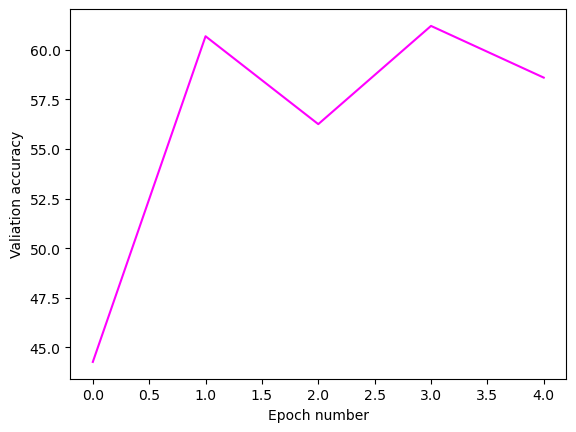

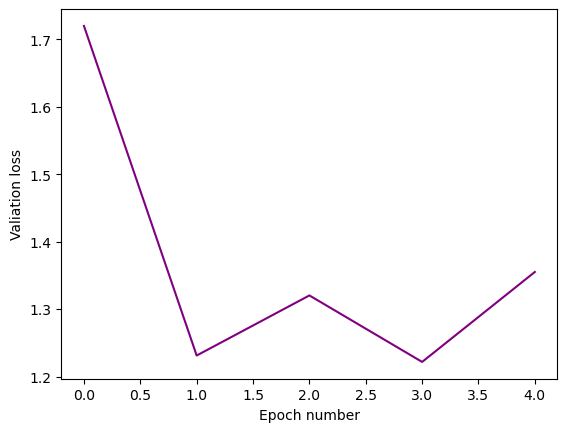

In [19]:
plt.plot(range(num_epochs), val_acc_list, color = "magenta")
plt.xlabel("Epoch number")
plt.ylabel("Valiation accuracy")
plt.show()  

plt.plot(range(num_epochs), val_losses, color = "purple")
plt.xlabel("Epoch number")
plt.ylabel("Valiation loss")
plt.show() 

<font color='green'>After running the model and calculating the overall accuracy, we can examine the data via a confusion matrix which highlights the accuracy by class.

[0 2 2 5 0 0 5 1 5 2 5 5 0 2 2 0 0 5 2 2 2 2 2 5 5 5 2 0 2 0 2 2 5 0 5 2 2
 0 2 5 2 5 5 5 5 2 2 4 0 2 0 5 2 0 0 2 5 1 2 2 3 5 5 2 5 5 0 0 2 2 2 0 0 2
 2 2 2 2 0 0 5 5 4 2 5 2 2 2 3 2 5 5 2 0 5 5 4 2 2 0 2 2 2 0 2 5 2 0 2 2 3
 5 0 5 0 2 2 5 2 5 2 0 2 0 0 5 5 5 1 1 0 2 2 2 2 2 0 2 2 2 0 1 0 5 2 0 2 2
 1 5 2 2 2 0 3 2 3 5 5 2 2 2 5 3 5 5 2 2 0 2 5 0 0 2 0 2 0 0 0 0 2 2 0 2 2
 2 0 2 2 2 2 5 0 0 5 5 0 0 5 0 2 2 4 5 4 0 5 2 2 1 5 0 3 0 5 2 5 5 3 5 5 0
 0 2 5 5 2 5 2 2 5 2 4 5 2 0 3 0 5 2 3 0 5 2 0 0 2 2 5 5 2 2 5 0 2 2 1 2 5
 5 3 5 0 2 5 4 5 2 2 0 4 5 3 2 2 0 3 2 5 2 5 0 5 5 4 2 0 0 2 5 0 5 5 0 2 5
 5 5 0 2 2 2 4 2 0 2 1 0 2 2 2 2 0 5 3 2 2 0 0 0 0 2 2 1 2 2 0 5 0 0 0 5 0
 2 0 0 2 5 2 2 0 5 0 5 0 0 0 5 5 0 0 2 5 2 3 0 0 5 5 5 2 0 0 0 2 5 2 2 5 5
 5 2 5 2 2 0 0 2 5 1 0 5 2 0 2 3 5 2 2 5 5 0 5 5 2 2 0 5 3 0 0 5 5 5 5 2 0
 0 0 5 2 2 5 5 3 0 5 0 2 2]


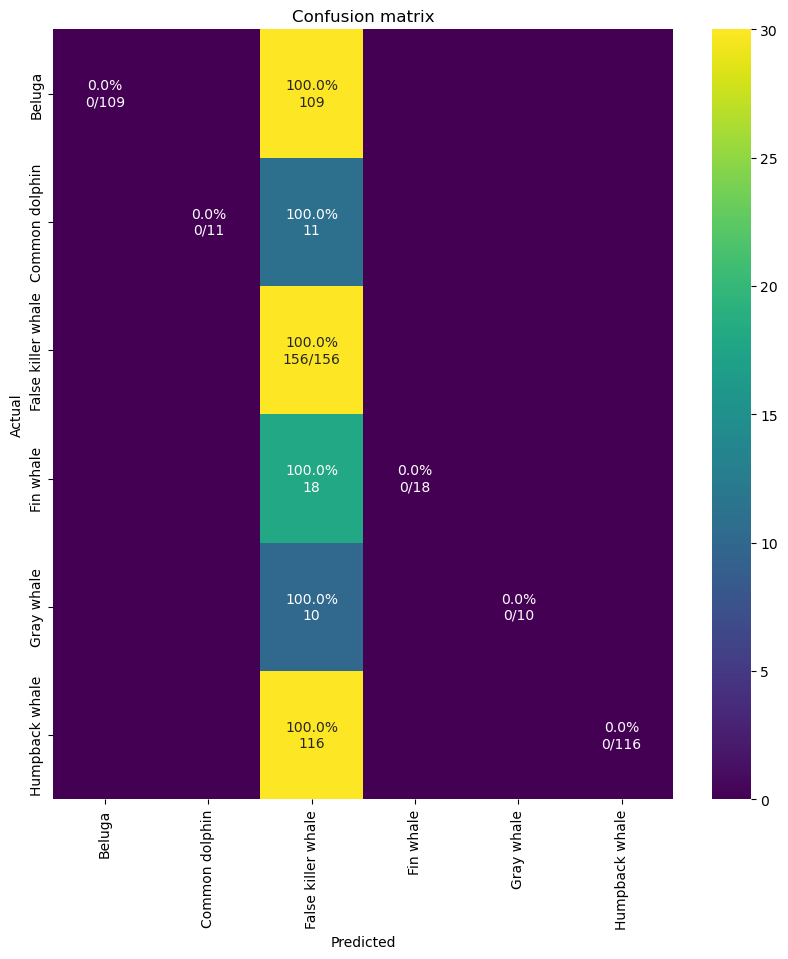

In [38]:
# predict the test dataset
def predict(model, dataset):
    dataset_prediction = []
    dataset_groundtruth = []
    model = model
    with torch.no_grad():
        for x, y_true in dataset:
            inp = x.unsqueeze(0).to(device)    
            y_pred = model(inp)
            dataset_prediction.append(y_pred.argmax().cpu().numpy())
            dataset_groundtruth.append(y_true)
    
    return np.array(dataset_prediction), np.array(dataset_groundtruth)
            
    # create seaborn heatmap with required labels
    ax=sns.heatmap(cm, annot=annot, fmt='', vmax=30, xticklabels=x_axis_labels, yticklabels=y_axis_labels)
    ax.set_title(title)

# Plot confusion matrix 
# orginally from Runqi Yang; 
# see https://gist.github.com/hitvoice/36cf44689065ca9b927431546381a3f7
def cm_analysis(y_true, y_pred, title, figsize=(10,10)):
    """
    Generate matrix plot of confusion matrix with pretty annotations.
    The plot image is saved to disk.
    args: 
      y_true:    true label of the data, with shape (nsamples,)
      y_pred:    prediction of the data, with shape (nsamples,)
      filename:  filename of figure file to save
      labels:    string array, name the order of class labels in the confusion matrix.
                 use `clf.classes_` if using scikit-learn models.
                 with shape (nclass,).
      ymap:      dict: any -> string, length == nclass.
                 if not None, map the labels & ys to more understandable strings.
                 Caution: original y_true, y_pred and labels must align.
      figsize:   the size of the figure plotted.
    """
    labels = ['Beluga','Common dolphin', 'False killer whale', 'Fin whale', 'Gray whale','Humpback whale']
    cm = confusion_matrix(y_true, y_pred)
    cm_sum = np.sum(cm, axis=1, keepdims=True)
    cm_perc = cm / cm_sum.astype(float) * 100
    annot = np.empty_like(cm).astype(str)
    nrows, ncols = cm.shape
    for i in range(nrows):
        for j in range(ncols):
            c = cm[i, j]
            p = cm_perc[i, j]
            if i == j:
                s = cm_sum[i]
                annot[i, j] = '%.1f%%\n%d/%d' % (p, c, s)
            elif c == 0:
                annot[i, j] = ''
            else:
                annot[i, j] = '%.1f%%\n%d' % (p, c)
    cm = pd.DataFrame(cm, index=labels, columns=labels)
    cm.index.name = 'Actual'
    cm.columns.name = 'Predicted'
    fig, ax = plt.subplots(figsize=figsize)
                              
    x_axis_labels = ['Beluga','Common dolphin', 'False killer whale', 'Fin whale', 'Gray whale','Humpback whale'] # labels for x-axis
    y_axis_labels = ['Beluga','Common dolphin', 'False killer whale', 'Fin whale', 'Gray whale','Humpback whale'] # labels for y-axis
    ax=sns.heatmap(cm, annot=annot, fmt='', vmax=30, xticklabels=x_axis_labels, yticklabels=y_axis_labels, cmap = "viridis")
    ax.set_title(title)

## This plot only contains the test set of data
## The test set of data has not been seen by the model yet
y_pred, y_true = predict(model, test_set)

print(y_true)
cm_analysis(y_true, y_pred, "Confusion matrix")

### What features did the model use to make decisions?

Based on the confusion matrices and validation loss, it is clear that the model is learning. To determine the features that are involved in decision making, there are a few possible approaches. One options is shown below, integrated gradients. 

#### Understanding feature importance using Integrated Gradients

<font color='green'>Integrated gradients is an attribution method. Attribution methods score the input data based on the prediction that the model makes using scores for each feature. The gradient is the signal that tells the network how much to increase or decrease a certain weight in the network during backpropogation. These gradients are overlaid onto the images to showcase the regions on the images that influence the weights.

Run the below code. 

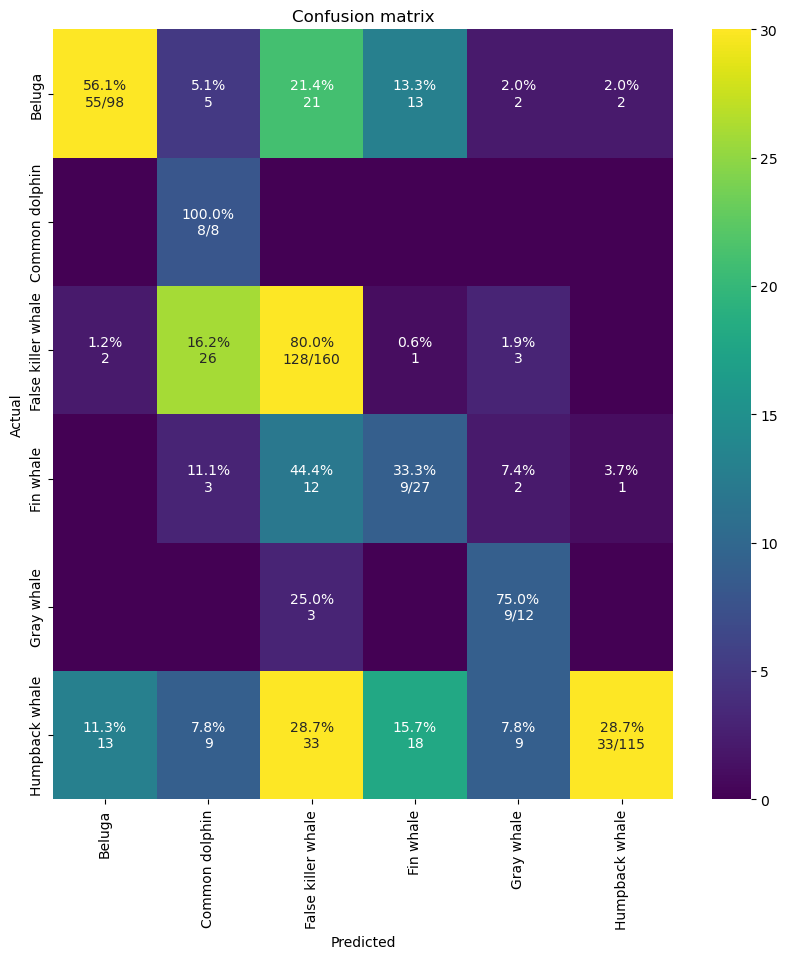

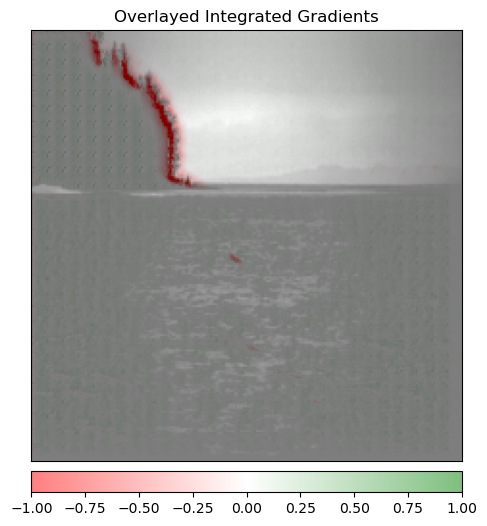

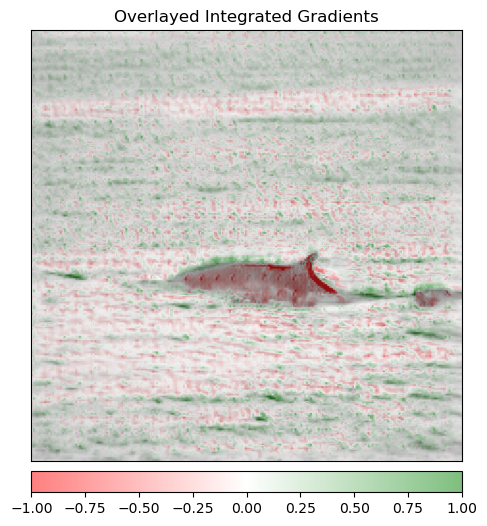

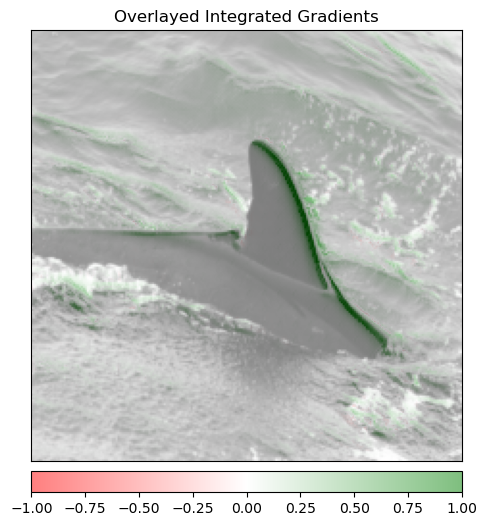

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
model.eval()

def predict(model, dataset):
    preds, gts = [], []
    with torch.no_grad():
        for x, y_true in dataset:
            inp = x.unsqueeze(0).to(device)              # FIX: move input to same device
            y_pred = model(inp)
            preds.append(y_pred.argmax(dim=1).item())     # FIX: correct argmax + scalar
            gts.append(int(y_true))
    return np.array(preds), np.array(gts)

def visualize_ig(idx):
    model.eval()

    x, y_true = test_set[idx]
    input_tensor = x.unsqueeze(0).to(device)              # FIX: move to GPU
    input_tensor.requires_grad_()

    target = int(y_true)

    ig = IntegratedGradients(model)
    attr_ig, delta = ig.attribute(
        input_tensor,
        target=target,
        baselines=torch.zeros_like(input_tensor),          # FIX: baseline on same device
        return_convergence_delta=True
    )

    # back to CPU for plotting
    attr_ig = attr_ig.squeeze(0).detach().cpu().permute(1, 2, 0).numpy()
    original_image = x.detach().cpu().permute(1, 2, 0).numpy()

    viz.visualize_image_attr(
        attr_ig,
        original_image,
        method="blended_heat_map",
        sign="all",
        show_colorbar=True,
        title="Overlayed Integrated Gradients"
    )

# run
y_pred, y_true = predict(model, test_set)
cm_analysis(y_true, y_pred, "Confusion matrix")

visualize_ig(0)
visualize_ig(8)
visualize_ig(20)

<font color='magenta'>Does the integrated gradient show what types of features the model used to classify the images? Do you notice any potential problems? (2 pts)

*Yes I see that the model is using the fin structre and overall silhouette of the animals to learn but it is also learning from the water around the animals which could be a problem.*

## Part 2 

Now that you have a sense for how to train a machine learning model, your task is to improve the success of our classification model.

**In three separate training events, make one (or more) modifications to the model training process, re-train the model, and report out your changes and whether they increased model accuracy. Why did you chose your particular change (curiousity, hypothesis, ect.)? Do you have ideas why your modifications were/were not successful?**

Types of changes that you can make include:
- [Using the pre-trained weights for ResNet18 (transfer learning)](https://docs.pytorch.org/vision/main/models/generated/torchvision.models.resnet18.html) 
- Changing hyperparameters (learning rate, batch size)
- [Changing transformation approach](https://docs.pytorch.org/vision/0.11/auto_examples/plot_transforms.html#sphx-glr-auto-examples-plot-transforms-py)
- [Changing the optimizer](https://docs.pytorch.org/docs/stable/optim.html)
- [Changing the model to a different pre-made model architecture](https://docs.pytorch.org/vision/main/models.html)
- Modifying the ResNet18 model
- Coming up with a whole new model!

If you decide to change any lines of code that are not in the below box, please add them to the box (DO NOT MODIFY ANY CODE ABOVE THIS MARKDOWN BOX - IT MAY BREAK PART 1). 

If your changes are ambitious, the code may take hours to run. If this is the case, please consider turning this notebook into a python script and running it via sBATCH. 

**Please note, you will NOT be graded by the success of your classifiers! It is okay if you are unable to improve the accuracy of the classifier**

#### Your Model 1 (10 pts)

<font color='magenta'>Describe your changes to the model training process (either changing something about the model, a hyperparameter, how data was inputted into the model, or another aspect) and why you selected those changes.

*I'm using the pre-trained weights for ResNet18 (transfer learning) because I'm curious about whether pretrained weights will work better than our custom weights.*


In [3]:
batchsize = 48
learning_rate=1e-3
epochs=5

train_loader = DataLoader(train_set, batch_size=batchsize, drop_last=True, sampler=train_sampler)
val_loader = DataLoader(val_set, batch_size=batchsize, drop_last=True, shuffle=True)
test_loader = DataLoader(test_set, batch_size=batchsize, drop_last=True, shuffle=True)

NameError: name 'DataLoader' is not defined

In [ ]:
## Model
 #########
## First, we create the basic block that will be used in our residual net
class BasicBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super(BasicBlock, self).__init__()
        ## Conv1: convolution layer, batch normalization, ReLU activation
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

        ## Conv2: convolution layer, batch normalization
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        ## Shortcut connection: adds input to output
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    # The forward method calls on each layer
    def forward(self, x):
        ## Conv1: convolution layer, batch normalization, ReLU activation
        out = self.conv1(x) 
        out = self.bn1(out)
        out = self.relu(out)
        ## Conv2: convolution layer, batch normalization
        out = self.conv2(out)
        out = self.bn2(out)
        ## Shortcut connection
        out += self.shortcut(x)
        ## Final activation
        out = self.relu(out)
        return out

############
## Next, we put together these building blocks and create our residual net
class ResNet18(nn.Module):
    # specify the number of classes that we are predicting
    def __init__(self, num_classes=6):
        super(ResNet18, self).__init__()
        # In channels = Num pixels in H + Num pixels in W
        self.in_channels = 64
        
        # First convolution set (convolution, batch norm, relu)
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)

        # Our building blocks
        # The numbers correspond to the matrix shape
        ### We increase the number of channels (i.e., the first number) as we go
        self.layer1 = self._make_layer(BasicBlock, 64, 2, stride=1)
        self.layer2 = self._make_layer(BasicBlock, 128, 2, stride=2)
        self.layer3 = self._make_layer(BasicBlock, 256, 2, stride=2)
        self.layer4 = self._make_layer(BasicBlock, 512, 2, stride=2)

        # Average pooling 
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))

        # Final layer that makes the classification
        self.fc = nn.Linear(512, num_classes)

    def _make_layer(self, block, out_channels, num_blocks, stride):
        strides = [stride] + [1]*(num_blocks-1)
        layers = []
        for stride in strides:
            layers.append(block(self.in_channels, out_channels, stride))
            self.in_channels = out_channels
        return nn.Sequential(*layers)

    def forward(self, x):
        # First convolution set (convolution, batch norm, relu)
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        # Our 4 building blocks
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)
        
        out = self.avgpool(out)
        out = out.view(out.size(0), -1)
        # Final layer that makes the classification
        out = self.fc(out)
        return out

## Getting our model and transferring it to the GPU
from torchvision.models import resnet18, ResNet18_Weights
model = resnet18(weights=ResNet18_Weights.DEFAULT)
model.fc = nn.Linear(model.fc.in_features, 6)
model = model.to(device)

#define loss function & optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

Epoch [1/5] | Batch #1 | Batch Accuracy 22.92%
Epoch [1/5] | Batch #2 | Batch Accuracy 47.92%
Epoch [1/5] | Batch #3 | Batch Accuracy 56.94%
Epoch [1/5] | Batch #4 | Batch Accuracy 59.90%
Epoch [1/5] | Batch #5 | Batch Accuracy 64.58%
Epoch [1/5] | Batch #6 | Batch Accuracy 69.44%
Epoch [1/5] | Batch #7 | Batch Accuracy 71.73%
Epoch [1/5] | Batch #8 | Batch Accuracy 73.70%
Epoch [1/5] | Batch #9 | Batch Accuracy 74.77%
Epoch [1/5] | Batch #10 | Batch Accuracy 76.25%
Epoch [1/5] | Batch #11 | Batch Accuracy 77.08%
Epoch [1/5] | Batch #12 | Batch Accuracy 78.30%
Epoch [1/5] | Batch #13 | Batch Accuracy 79.17%
Epoch [1/5] | Batch #14 | Batch Accuracy 79.76%
Epoch [1/5] | Batch #15 | Batch Accuracy 80.28%
Epoch [1/5] | Batch #16 | Batch Accuracy 80.86%
Epoch [1/5] | Batch #17 | Batch Accuracy 81.74%
Epoch [1/5] | Batch #18 | Batch Accuracy 82.41%
Epoch [1/5] | Batch #19 | Batch Accuracy 82.68%
Epoch [1/5] | Batch #20 | Batch Accuracy 82.92%
Epoch [1/5] | Batch #21 | Batch Accuracy 83.23%
E

train_loss,█▃▁▁▁
validation_accuracy,▂▁▃▆█
validation_loss,█▇▆▁▁
train_loss,0.09715
validation_accuracy,92.70833
validation_loss,0.2802


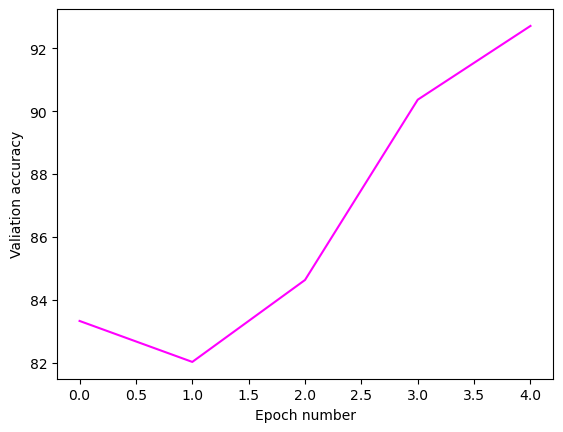

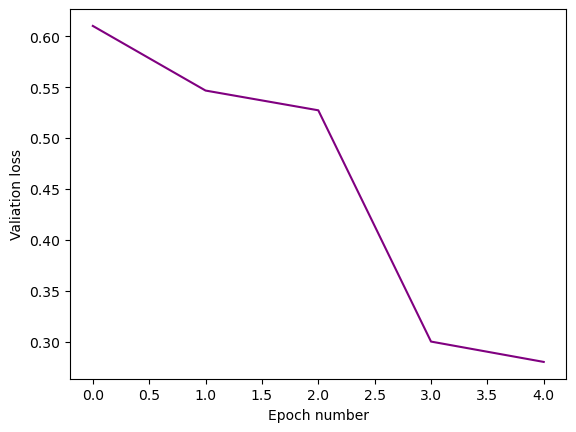

NameError: name 'cm_analysis' is not defined

In [ ]:
wandb.init(
    project="BGMP_HappyWhale",
    name="Daniella-HappyWhale-SpeciesDataset-hyperparameters_mod3", ##update this with your name
    config={"learning rate":learning_rate, # possibly update
        "architecture": "resnet18_pretrained",
        "dataset": "Species",
        "epochs": epochs, "batch_size":batchsize}  # possibly update
) 

batch=0
num_epochs = epochs
train_losses, train_acc_list, val_losses, val_acc_list = [], [], [],[]

for epoch in range(num_epochs):
    # Setting model to "training mode"
    model.train()
    running_loss = 0.0
    correct, total = 0, 0

    # For each batch of data within the loader
    for inputs, labels in train_loader:
        # Send our input images and their labels to the GPU
        inputs, labels = inputs.to(device), labels.to(device)
        # Zero the gradients
        optimizer.zero_grad()
        # Inputting our training images into the model
        # and Predicting the image classification label
        outputs = model(inputs)
        # Figuring out the loss from our predictions
        loss = criterion(outputs, labels)
        # Compute gradients (aka backward pass)
        loss.backward()
        # Update model parameters
        optimizer.step()

        # Adding the loss to our running sum
        # Loss is calculated for each batch within an epoch
        running_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        batch+=1
        print(f'Epoch [{epoch+1}/{num_epochs}] | Batch #{batch} | Batch Accuracy {(correct/total)*100:.2f}%')


    # Getting metrics for our training pass 
    train_loss = running_loss / len(train_loader.dataset)
    train_acc = 100. * correct / total
    train_losses.append(train_loss)
    train_acc_list.append(train_acc)
    
    # Switching our model to "evaluation mode"
    model.eval()
    running_loss = 0.0
    correct, total = 0, 0
    # Disable gradient calculation b/c we are evalulating the model
    with torch.no_grad():
        # Load in batches of our validation data
        for inputs, labels in val_loader:
            # Send test images and labels to the GPU
            inputs, labels = inputs.to(device), labels.to(device)
            # Predict the image classification label
            outputs = model(inputs)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            # Figuring out how many predicted labels = true labels
            correct += predicted.eq(labels).sum().item()

            # Figuring out the loss from our predictions
            loss = criterion(outputs, labels)
            # Adding the loss to our running sum
            # Loss is calculated for each batch within an epoch
            running_loss += loss.item() * inputs.size(0)
    # Getting our accuracy from our test data
    val_acc = 100. * correct / total
    val_acc_list.append(val_acc)
    # Getting the loss from our test data
    val_loss = running_loss / len(val_loader.dataset)
    val_losses.append(val_loss)
    
    print(f'Epoch [{epoch+1}/{num_epochs}] Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}% | Val Loss: {val_loss:.2f}%')

    # log metrics to wandb
    wandb.log({"validation_accuracy": val_acc, "validation_loss": val_loss, "train_loss":train_loss})

wandb.finish()

plt.plot(range(epochs), val_acc_list, color = "magenta")
plt.xlabel("Epoch number")
plt.ylabel("Valiation accuracy")
plt.show()  

plt.plot(range(epochs), val_losses, color = "purple")
plt.xlabel("Epoch number")
plt.ylabel("Valiation loss")
plt.show()  

y_pred, y_true = predict(model, test_set)
cm_analysis(y_true, y_pred, "Confusion matrix")

<font color='magenta'>Were your changes successful? Do you have ideas why your changes were successful or not? 

*Using pretrained weights definetly improved accuracy and loss. I think this happened because the retrained initialization helped optimixation converge faster rather than random initalization and the pretrained weights act like strong prior knowledge so this probably reduced overfitting.*

#### Your Model 2 (10pts)

<font color='magenta'>Describe your changes to the model training process (either changing something about the model, a hyperparameter, how data was inputted into the model, or another aspect) and why you selected those changes.

*Changed learning rate from 1e-3 to 1e-4 to see if the slower model would be more stable*

In [36]:
batchsize = 48
learning_rate=1e-4
epochs=5

train_loader = DataLoader(train_set, batch_size=batchsize, drop_last=True, sampler=train_sampler)
val_loader = DataLoader(val_set, batch_size=batchsize, drop_last=True, shuffle=True)
test_loader = DataLoader(test_set, batch_size=batchsize, drop_last=True, shuffle=True)

In [37]:
## Model
#########
## First, we create the basic block that will be used in our residual net
class BasicBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super(BasicBlock, self).__init__()
        ## Conv1: convolution layer, batch normalization, ReLU activation
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

        ## Conv2: convolution layer, batch normalization
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        ## Shortcut connection: adds input to output
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    # The forward method calls on each layer
    def forward(self, x):
        ## Conv1: convolution layer, batch normalization, ReLU activation
        out = self.conv1(x) 
        out = self.bn1(out)
        out = self.relu(out)
        ## Conv2: convolution layer, batch normalization
        out = self.conv2(out)
        out = self.bn2(out)
        ## Shortcut connection
        out += self.shortcut(x)
        ## Final activation
        out = self.relu(out)
        return out

############
## Next, we put together these building blocks and create our residual net
class ResNet18(nn.Module):
    # specify the number of classes that we are predicting
    def __init__(self, num_classes=6):
        super(ResNet18, self).__init__()
        # In channels = Num pixels in H + Num pixels in W
        self.in_channels = 64
        
        # First convolution set (convolution, batch norm, relu)
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)

        # Our building blocks
        # The numbers correspond to the matrix shape
        ### We increase the number of channels (i.e., the first number) as we go
        self.layer1 = self._make_layer(BasicBlock, 64, 2, stride=1)
        self.layer2 = self._make_layer(BasicBlock, 128, 2, stride=2)
        self.layer3 = self._make_layer(BasicBlock, 256, 2, stride=2)
        self.layer4 = self._make_layer(BasicBlock, 512, 2, stride=2)

        # Average pooling 
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))

        # Final layer that makes the classification
        self.fc = nn.Linear(512, num_classes)

    def _make_layer(self, block, out_channels, num_blocks, stride):
        strides = [stride] + [1]*(num_blocks-1)
        layers = []
        for stride in strides:
            layers.append(block(self.in_channels, out_channels, stride))
            self.in_channels = out_channels
        return nn.Sequential(*layers)

    def forward(self, x):
        # First convolution set (convolution, batch norm, relu)
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        # Our 4 building blocks
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)
        
        out = self.avgpool(out)
        out = out.view(out.size(0), -1)
        # Final layer that makes the classification
        out = self.fc(out)
        return out

## Getting our model and transferring it to the GPU
model = ResNet18().to(device)

#define loss function & optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

In [19]:
wandb.init(
    project="BGMP_HappyWhale",
    name="Daniella-HappyWhale-SpeciesDataset-hyperparameters_mod2", ##update this with your name
    config={"learning rate":.0001, # possibly update
        "architecture": "CNN",
        "dataset": "Species",
        "epochs": 5, "batch_size":48}  # possibly update
) 

batch=0
num_epochs = epochs
train_losses = []
train_acc_list = []
val_losses = []
val_acc_list = []

for epoch in range(num_epochs):
    # Setting model to "training mode"
    model.train()
    running_loss = 0.0
    correct, total = 0, 0

    # For each batch of data within the loader
    for inputs, labels in train_loader:
        # Send our input images and their labels to the GPU
        inputs, labels = inputs.to(device), labels.to(device)
        # Zero the gradients
        optimizer.zero_grad()
        # Inputting our training images into the model
        # and Predicting the image classification label
        outputs = model(inputs)
        # Figuring out the loss from our predictions
        loss = criterion(outputs, labels)
        # Compute gradients (aka backward pass)
        loss.backward()
        # Update model parameters
        optimizer.step()

        # Adding the loss to our running sum
        # Loss is calculated for each batch within an epoch
        running_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        batch+=1
        print(f'Epoch [{epoch+1}/{num_epochs}] | Batch #{batch} | Batch Accuracy {(correct/total)*100:.2f}%')


    # Getting metrics for our training pass 
    train_loss = running_loss / len(train_loader.dataset)
    train_acc = 100. * correct / total
    train_losses.append(train_loss)
    train_acc_list.append(train_acc)
    
    # Switching our model to "evaluation mode"
    model.eval()
    running_loss = 0.0
    correct, total = 0, 0
    # Disable gradient calculation b/c we are evalulating the model
    with torch.no_grad():
        # Load in batches of our validation data
        for inputs, labels in val_loader:
            # Send test images and labels to the GPU
            inputs, labels = inputs.to(device), labels.to(device)
            # Predict the image classification label
            outputs = model(inputs)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            # Figuring out how many predicted labels = true labels
            correct += predicted.eq(labels).sum().item()

            # Figuring out the loss from our predictions
            loss = criterion(outputs, labels)
            # Adding the loss to our running sum
            # Loss is calculated for each batch within an epoch
            running_loss += loss.item() * inputs.size(0)
    # Getting our accuracy from our test data
    val_acc = 100. * correct / total
    val_acc_list.append(val_acc)
    # Getting the loss from our test data
    val_loss = running_loss / len(val_loader.dataset)
    val_losses.append(val_loss)
    
    print(f'Epoch [{epoch+1}/{num_epochs}] Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}% | Val Loss: {val_loss:.2f}%')

    # log metrics to wandb
    wandb.log({"validation_accuracy": val_acc, "validation_loss": val_loss, "train_loss":train_loss})

wandb.finish()

plt.plot(range(epochs), val_acc_list, color = "magenta")
plt.xlabel("Epoch number")
plt.ylabel("Valiation accuracy")
plt.show()  

plt.plot(range(epochs), val_losses, color = "purple")
plt.xlabel("Epoch number")
plt.ylabel("Valiation loss")
plt.show()  

y_pred, y_true = predict(model, test_set)
cm_analysis(y_true, y_pred, "Confusion matrix")

Epoch [1/5] | Batch #1 | Batch Accuracy 91.67%
Epoch [1/5] | Batch #2 | Batch Accuracy 86.46%
Epoch [1/5] | Batch #3 | Batch Accuracy 84.03%
Epoch [1/5] | Batch #4 | Batch Accuracy 86.46%
Epoch [1/5] | Batch #5 | Batch Accuracy 85.42%
Epoch [1/5] | Batch #6 | Batch Accuracy 84.03%
Epoch [1/5] | Batch #7 | Batch Accuracy 84.23%
Epoch [1/5] | Batch #8 | Batch Accuracy 83.85%
Epoch [1/5] | Batch #9 | Batch Accuracy 84.49%
Epoch [1/5] | Batch #10 | Batch Accuracy 84.38%
Epoch [1/5] | Batch #11 | Batch Accuracy 83.52%
Epoch [1/5] | Batch #12 | Batch Accuracy 83.68%
Epoch [1/5] | Batch #13 | Batch Accuracy 83.65%
Epoch [1/5] | Batch #14 | Batch Accuracy 83.63%
Epoch [1/5] | Batch #15 | Batch Accuracy 82.78%
Epoch [1/5] | Batch #16 | Batch Accuracy 82.81%
Epoch [1/5] | Batch #17 | Batch Accuracy 82.84%
Epoch [1/5] | Batch #18 | Batch Accuracy 82.99%
Epoch [1/5] | Batch #19 | Batch Accuracy 83.44%
Epoch [1/5] | Batch #20 | Batch Accuracy 83.44%
Epoch [1/5] | Batch #21 | Batch Accuracy 83.33%
E

KeyboardInterrupt: 

<font color='magenta'>Were your changes successful? Do you have ideas why your changes were successful or not? 

*Your answer here*

#### Your Model 3 (10 pts)

<font color='magenta'>Describe your changes to the model training process (either changing something about the model, a hyperparameter, how data was inputted into the model, or another aspect) and why you selected those changes.

*use a different transform for train_set than for val_set/test_set to try to force the model to rely on whale shape/fin features instead of background water and improve generalization.*

In [20]:
# define transforms
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

eval_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

# load full dataset WITHOUT transform
full_dataset = datasets.ImageFolder(images)

# split indices
train_size = int(0.7 * len(full_dataset))
val_size = int(0.15 * len(full_dataset))
test_size = len(full_dataset) - (train_size + val_size)

train_indices, val_indices, test_indices = torch.utils.data.random_split(
    range(len(full_dataset)), [train_size, val_size, test_size]
)

# rebuild datasets with transforms
train_set = torch.utils.data.Subset(
    datasets.ImageFolder(images, transform=train_transform),
    train_indices.indices
)

val_set = torch.utils.data.Subset(
    datasets.ImageFolder(images, transform=eval_transform),
    val_indices.indices
)

test_set = torch.utils.data.Subset(
    datasets.ImageFolder(images, transform=eval_transform),
    test_indices.indices
)



In [21]:
batchsize = 48
learning_rate=1e-3
epochs=5

train_loader = DataLoader(train_set, batch_size=batchsize, drop_last=True, sampler=train_sampler)
val_loader = DataLoader(val_set, batch_size=batchsize, drop_last=True, shuffle=True)
test_loader = DataLoader(test_set, batch_size=batchsize, drop_last=True, shuffle=True)

In [22]:
## Model
#########
## First, we create the basic block that will be used in our residual net
class BasicBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super(BasicBlock, self).__init__()
        ## Conv1: convolution layer, batch normalization, ReLU activation
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

        ## Conv2: convolution layer, batch normalization
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        ## Shortcut connection: adds input to output
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    # The forward method calls on each layer
    def forward(self, x):
        ## Conv1: convolution layer, batch normalization, ReLU activation
        out = self.conv1(x) 
        out = self.bn1(out)
        out = self.relu(out)
        ## Conv2: convolution layer, batch normalization
        out = self.conv2(out)
        out = self.bn2(out)
        ## Shortcut connection
        out += self.shortcut(x)
        ## Final activation
        out = self.relu(out)
        return out

############
## Next, we put together these building blocks and create our residual net
class ResNet18(nn.Module):
    # specify the number of classes that we are predicting
    def __init__(self, num_classes=6):
        super(ResNet18, self).__init__()
        # In channels = Num pixels in H + Num pixels in W
        self.in_channels = 64
        
        # First convolution set (convolution, batch norm, relu)
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)

        # Our building blocks
        # The numbers correspond to the matrix shape
        ### We increase the number of channels (i.e., the first number) as we go
        self.layer1 = self._make_layer(BasicBlock, 64, 2, stride=1)
        self.layer2 = self._make_layer(BasicBlock, 128, 2, stride=2)
        self.layer3 = self._make_layer(BasicBlock, 256, 2, stride=2)
        self.layer4 = self._make_layer(BasicBlock, 512, 2, stride=2)

        # Average pooling 
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))

        # Final layer that makes the classification
        self.fc = nn.Linear(512, num_classes)

    def _make_layer(self, block, out_channels, num_blocks, stride):
        strides = [stride] + [1]*(num_blocks-1)
        layers = []
        for stride in strides:
            layers.append(block(self.in_channels, out_channels, stride))
            self.in_channels = out_channels
        return nn.Sequential(*layers)

    def forward(self, x):
        # First convolution set (convolution, batch norm, relu)
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        # Our 4 building blocks
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)
        
        out = self.avgpool(out)
        out = out.view(out.size(0), -1)
        # Final layer that makes the classification
        out = self.fc(out)
        return out

## Getting our model and transferring it to the GPU
model = ResNet18().to(device)

#define loss function & optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

Epoch [1/5] | Batch #1 | Batch Accuracy 4.17%
Epoch [1/5] | Batch #2 | Batch Accuracy 20.83%
Epoch [1/5] | Batch #3 | Batch Accuracy 27.08%
Epoch [1/5] | Batch #4 | Batch Accuracy 31.25%
Epoch [1/5] | Batch #5 | Batch Accuracy 31.67%
Epoch [1/5] | Batch #6 | Batch Accuracy 32.29%
Epoch [1/5] | Batch #7 | Batch Accuracy 34.23%
Epoch [1/5] | Batch #8 | Batch Accuracy 35.94%
Epoch [1/5] | Batch #9 | Batch Accuracy 36.81%
Epoch [1/5] | Batch #10 | Batch Accuracy 36.46%
Epoch [1/5] | Batch #11 | Batch Accuracy 37.12%
Epoch [1/5] | Batch #12 | Batch Accuracy 37.15%
Epoch [1/5] | Batch #13 | Batch Accuracy 37.18%
Epoch [1/5] | Batch #14 | Batch Accuracy 37.80%
Epoch [1/5] | Batch #15 | Batch Accuracy 38.06%
Epoch [1/5] | Batch #16 | Batch Accuracy 38.28%
Epoch [1/5] | Batch #17 | Batch Accuracy 38.11%
Epoch [1/5] | Batch #18 | Batch Accuracy 38.43%
Epoch [1/5] | Batch #19 | Batch Accuracy 38.60%
Epoch [1/5] | Batch #20 | Batch Accuracy 39.38%
Epoch [1/5] | Batch #21 | Batch Accuracy 39.68%
Ep

train_loss,█▃▂▂▁
validation_accuracy,▁▆█▅▅
validation_loss,▅▃▁▃█
train_loss,0.91675
validation_accuracy,53.64583
validation_loss,1.51951


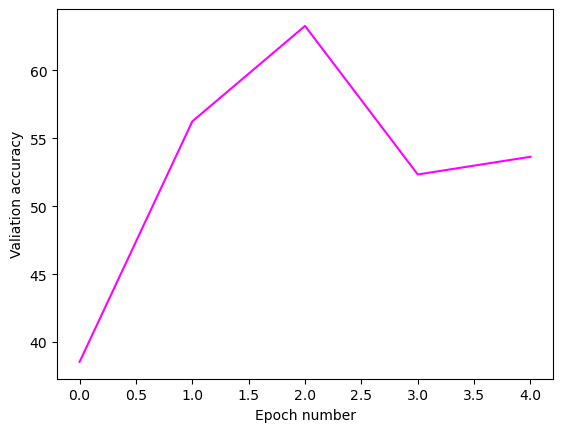

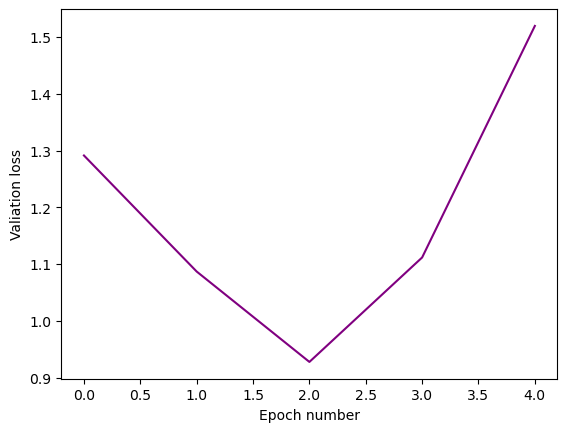

NameError: name 'predict' is not defined

In [24]:
wandb.init(
    project="BGMP_HappyWhale",
    name="Daniella-HappyWhale-SpeciesDataset-hyperparameters_mod1", ##update this with your name
    config={"learning rate":.001, # possibly update
        "architecture": "CNN",
        "dataset": "Species",
        "epochs": 3, "batch_size":48}  # possibly update
) 

batch=0
num_epochs = epochs
train_losses, train_acc_list, val_losses, val_acc_list = [], [], [],[]

for epoch in range(num_epochs):
    # Setting model to "training mode"
    model.train()
    running_loss = 0.0
    correct, total = 0, 0

    # For each batch of data within the loader
    for inputs, labels in train_loader:
        # Send our input images and their labels to the GPU
        inputs, labels = inputs.to(device), labels.to(device)
        # Zero the gradients
        optimizer.zero_grad()
        # Inputting our training images into the model
        # and Predicting the image classification label
        outputs = model(inputs)
        # Figuring out the loss from our predictions
        loss = criterion(outputs, labels)
        # Compute gradients (aka backward pass)
        loss.backward()
        # Update model parameters
        optimizer.step()

        # Adding the loss to our running sum
        # Loss is calculated for each batch within an epoch
        running_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        batch+=1
        print(f'Epoch [{epoch+1}/{num_epochs}] | Batch #{batch} | Batch Accuracy {(correct/total)*100:.2f}%')


    # Getting metrics for our training pass 
    train_loss = running_loss / len(train_loader.dataset)
    train_acc = 100. * correct / total
    train_losses.append(train_loss)
    train_acc_list.append(train_acc)
    
    # Switching our model to "evaluation mode"
    model.eval()
    running_loss = 0.0
    correct, total = 0, 0
    # Disable gradient calculation b/c we are evalulating the model
    with torch.no_grad():
        # Load in batches of our validation data
        for inputs, labels in val_loader:
            # Send test images and labels to the GPU
            inputs, labels = inputs.to(device), labels.to(device)
            # Predict the image classification label
            outputs = model(inputs)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            # Figuring out how many predicted labels = true labels
            correct += predicted.eq(labels).sum().item()

            # Figuring out the loss from our predictions
            loss = criterion(outputs, labels)
            # Adding the loss to our running sum
            # Loss is calculated for each batch within an epoch
            running_loss += loss.item() * inputs.size(0)
    # Getting our accuracy from our test data
    val_acc = 100. * correct / total
    val_acc_list.append(val_acc)
    # Getting the loss from our test data
    val_loss = running_loss / len(val_loader.dataset)
    val_losses.append(val_loss)
    
    print(f'Epoch [{epoch+1}/{num_epochs}] Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}% | Val Loss: {val_loss:.2f}%')

    # log metrics to wandb
    wandb.log({"validation_accuracy": val_acc, "validation_loss": val_loss, "train_loss":train_loss})

wandb.finish()

plt.plot(range(epochs), val_acc_list, color = "magenta")
plt.xlabel("Epoch number")
plt.ylabel("Valiation accuracy")
plt.show()  

plt.plot(range(epochs), val_losses, color = "purple")
plt.xlabel("Epoch number")
plt.ylabel("Valiation loss")
plt.show()  

y_pred, y_true = predict(model, test_set)
cm_analysis(y_true, y_pred, "Confusion matrix")

<font color='magenta'>Were your changes successful? Do you have ideas why your changes were successful or not? 

*Your answer here*

<font color='magenta'>Summarize your 3 steps, their success, and what you learned (5 pts)

*Your answer here*